In [ ]:
#实战线性回归之lasso回归、岭回归、梯度下降

import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(data_home="./data")

df = pd.DataFrame(data.data, columns=data.feature_names)
df['price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np

# 提取特征和标签
X = df.drop('price',axis = 1).values
y = df['price'].values
print(X.shape)
print(y.shape)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 训练线性回归模型
lr = LinearRegression()
lr.fit(X_train, y_train)

# 输出模型参数
print(lr.coef_)
print(lr.intercept_)

# 预测与评估
y_pred = lr.predict(X_test)

mse = np.mean((y_pred - y_test) ** 2)
print(f"线性回归测试集均方误差 MSE: {mse}")


(20640, 8)
(20640,)
[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
2.071946937378619
线性回归测试集均方误差 MSE: 0.5558915986952442


In [4]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(eta0=0.01, penalty='l2', max_iter=1000)  # 初始化随机梯度下降回归器，设置学习率0.01、L2正则化、最大迭代1000次

sgd_reg.fit(X_train, y_train)  # 使用训练数据拟合模型

print(sgd_reg.coef_)  # 打印模型系数（特征权重）
print(sgd_reg.intercept_)  # 打印模型截距

y_pred_sgd = sgd_reg.predict(X_test)  # 对测试集进行预测

mse_sgd = np.mean((y_pred_sgd - y_test) ** 2)  # 计算测试集均方误差
print(f"SGDRegressor测试集均方误差 MSE: {mse_sgd}")  # 打印测试集MSE结果

[ 0.84000503  0.12971787 -0.28963273  0.33760564  0.00873867  0.0127076
 -0.90008212 -0.8808143 ]
[2.07875422]
SGDRegressor测试集均方误差 MSE: 0.5577161069106154


In [8]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.001)  # 创建Lasso回归模型，设置正则化强度alpha=0.001
lasso_reg.fit(X_train, y_train)  # 使用训练集拟合模型

print("Lasso回归系数:", lasso_reg.coef_)  # 输出训练后模型的回归系数

y_pred_lasso = lasso_reg.predict(X_test)  # 使用测试集进行预测，得到预测值

mse_lasso = np.mean((y_pred_lasso - y_test) ** 2)  # 计算预测值与真实值之间的均方误差
print(f"Lasso回归测试集均方误差 MSE: {mse_lasso}")  # 输出测试集的均方误差

Lasso回归系数: [ 0.84914038  0.12334631 -0.28127333  0.32604963 -0.00106185 -0.03988954
 -0.88582217 -0.85809324]
Lasso回归测试集均方误差 MSE: 0.5544913600832686


array([[-2.50919762],
       [ 9.01428613],
       [ 4.63987884],
       [ 1.97316968],
       [-6.87962719],
       [-6.88010959],
       [-8.83832776],
       [ 7.32352292],
       [ 2.02230023],
       [ 4.16145156],
       [-9.58831011],
       [ 9.39819704],
       [ 6.64885282],
       [-5.75321779],
       [-6.36350066],
       [-6.3319098 ],
       [-3.91515514],
       [ 0.49512863],
       [-1.36109963],
       [-4.1754172 ],
       [ 2.23705789],
       [-7.21012279],
       [-4.15710703],
       [-2.67276313],
       [-0.87860032],
       [ 5.70351923],
       [-6.00652436],
       [ 0.28468877],
       [ 1.84829138],
       [-9.07099175],
       [ 2.15089704],
       [-6.58951753],
       [-8.69896814],
       [ 8.97771075],
       [ 9.31264066],
       [ 6.16794696],
       [-3.90772462],
       [-8.04655772],
       [ 3.68466053],
       [-1.19695013],
       [-7.5592353 ],
       [-0.0964618 ],
       [-9.31222958],
       [ 8.18640804],
       [-4.82440037],
       [ 3

(100, 1)
(100, 10)
Ridge回归测试集均方误差 MSE: 0.7517439867831641
[ 9.60777148e-01  7.31445523e-01 -1.50281322e-01 -1.53362703e-01
  1.03889113e-01  6.95770548e-02 -2.03004890e-02 -1.19919764e-02
  1.18419338e-03  6.67557140e-04]


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


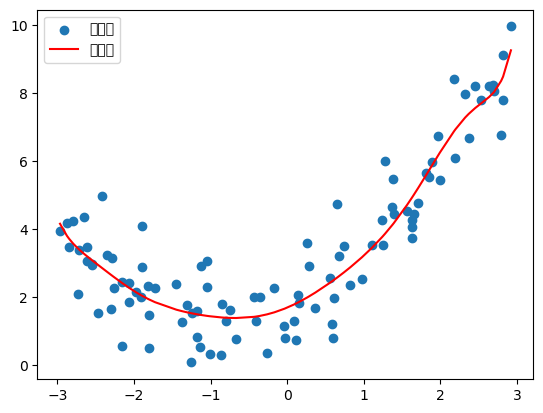

array([ 9.60777148e-01,  7.31445523e-01, -1.50281322e-01, -1.53362703e-01,
        1.03889113e-01,  6.95770548e-02, -2.03004890e-02, -1.19919764e-02,
        1.18419338e-03,  6.67557140e-04])

In [ ]:
np.random.seed(42)  # 设置随机种子，确保结果可重复
x = np.random.uniform(-3, 3, size=100)  # 生成100个均匀分布的随机数，范围为[-10, 10]
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0,1,size=100)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

# 初始化Ridge回归模型
model = Ridge()

# 将x转换为列向量，符合sklearn的输入要求
X = x.reshape(-1, 1)
print(X.shape)

# 构造多项式特征矩阵，包含x的1到10次方
X2 = np.hstack([X,X ** 2, X ** 3, X ** 4, X ** 5, X ** 6, X ** 7, X ** 8, X ** 9, X ** 10])
print(X2.shape)

# 使用构造的多项式特征训练Ridge模型
model.fit(X2, y)

# 用训练好的模型进行预测
y_pred = model.predict(X2)

# 计算并输出均方误差
mse = mean_squared_error(y, y_pred)
print(f"Ridge回归测试集均方误差 MSE: {mse}")
print(model.coef_)

# 绘制真实值与预测值的对比图
plt.scatter(x, y, label='真实值')
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red', label='预测值')
plt.legend()
plt.show()
# 输出模型系数
model.coef_

(100, 1)
(100, 10)
均方误差 MSE: 0.7399087981911175
[ 1.39370794  1.50418924 -0.6511855  -0.76883894  0.28688014  0.25430262
 -0.04664835 -0.0354002   0.00248978  0.00172481]


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


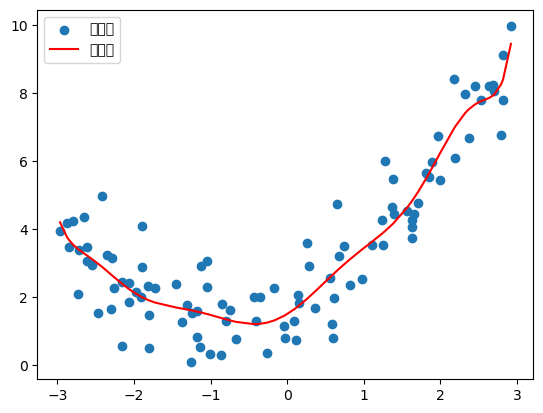

array([ 1.39370794,  1.50418924, -0.6511855 , -0.76883894,  0.28688014,
        0.25430262, -0.04664835, -0.0354002 ,  0.00248978,  0.00172481])

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# 将x转换为列向量，符合sklearn的输入要求
X = x.reshape(-1, 1)
print(X.shape)

# 构造多项式特征矩阵（1次到10次）
X2 = np.hstack([X,X ** 2, X ** 3, X ** 4, X ** 5, X ** 6, X ** 7, X ** 8, X ** 9, X ** 10])
print(X2.shape)

# 使用线性回归模型拟合多项式特征
model.fit(X2, y)

# 基于训练数据预测
y_pred = model.predict(X2)

# 计算并打印均方误差
mse = mean_squared_error(y, y_pred)
print(f"均方误差 MSE: {mse}")
print(model.coef_)

# 绘制真实值与预测值对比图
plt.scatter(x, y, label='真实值')
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red', label='预测值')
plt.legend()
plt.show()

# 输出模型系数
model.coef_